In [1]:
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'

In [4]:
import jax
import numpy as np
import pandas as pd
from copy import deepcopy
from aim_resolve import OptimizeKLConfig, SignalSpace, SignalGrid, signal_response, radio_data, image_data, get_builders, plot_arrays

In [14]:
data_dir = '/scratch/users/rfuchs/packages/aim-resolve/steering/data/runs/files/test512_10.pkl'

data = image_data(fname=data_dir, idx=1)
data.grid = SignalGrid.build(space=data.grid.space, fov=['1deg', '1deg'])
print(data)

space = SignalSpace.build(shape=data.grid.space, fov=['1deg', '1deg'])
print(space)

ImageData:
  prefix:	data
  image shape:	(512, 512)
  # pixel:	262144
  grid fov:	(np.float64(0.017453292519943295), np.float64(0.017453292519943295))
SignalSpace(shape=(512, 512), distances=(3.408846195301425e-05, 3.408846195301425e-05), center=(0.0, 0.0), rotation=0.0)


In [15]:
obs_dir = '/scratch/users/rfuchs/data/eso_986-1137mhz.npz'

obs = radio_data(fname=obs_dir)
obs = obs.get_freqs([3])
print(obs)

Observation:
  source name:		None
  visibilities shape:	(1, 3668965, 1)
  # visibilities:	3668965
  frequency range:	1061.954 -- 1061.954 MHz
  polarizations:	I
  shortest baseline:	0.0 m -> inf deg
  longest baseline:	7697.6 m -> 7.565 arcsec
  flagged:		1.1%


/scratch/users/rfuchs/packages/aim-resolve/src/aim_resolve/resolve/observation.py:296: RuntimeWarning: divide by zero encountered in scalar divide
  short1 = 1/(short0*self.freq.min()/SPEEDOFLIGHT)


In [16]:
vis = signal_response(space, obs, True)(data.val)
print(vis.shape)

(1, 3668965, 1)


In [17]:
key = jax.random.PRNGKey(4)
n_std = 0.1
noise = n_std * jax.random.normal(key, vis.shape, dtype=vis.dtype)
noisy_vis = vis + noise

print(vis)
print(noisy_vis)

[[[-0.50541097+8.65380391e+00j]
  [-6.7275505 +2.63274337e+00j]
  [-2.03820191+1.77081828e+01j]
  ...
  [ 0.13568869-1.23553638e-01j]
  [-0.04846689+6.91716421e-03j]
  [ 0.00892048+3.14234611e-02j]]]
[[[-0.56903208 +8.61104271j]
  [-6.80377864 +2.69969441j]
  [-2.02067855+17.81334407j]
  ...
  [ 0.1130345  -0.19747432j]
  [ 0.01017079 -0.07534685j]
  [ 0.09827102 +0.11073244j]]]


In [18]:
obs_new = deepcopy(obs)

idx = pd.MultiIndex.from_product([obs.pol, obs.freq], names=['pol', 'freq'])
vis_T = np.transpose(noisy_vis, (1,0,2)).reshape((noisy_vis.shape[1], -1))
df_vis = pd.DataFrame(vis_T, columns=idx)
obs_new._vis = df_vis
print(obs_new)

Observation:
  source name:		None
  visibilities shape:	(1, 3668965, 1)
  # visibilities:	3668965
  frequency range:	1061.954 -- 1061.954 MHz
  polarizations:	I
  shortest baseline:	0.0 m -> inf deg
  longest baseline:	7697.6 m -> 7.565 arcsec
  flagged:		1.1%


/scratch/users/rfuchs/packages/aim-resolve/src/aim_resolve/resolve/observation.py:296: RuntimeWarning: divide by zero encountered in scalar divide
  short1 = 1/(short0*self.freq.min()/SPEEDOFLIGHT)


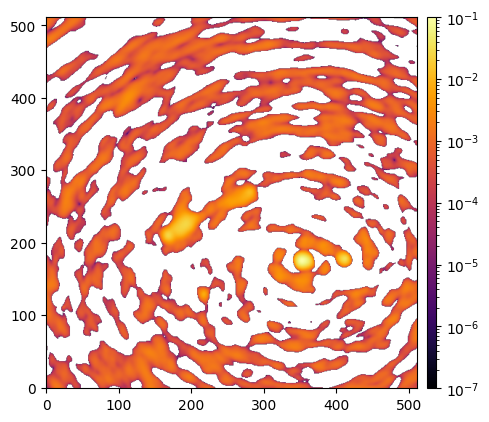

In [20]:
dirty = obs_new.dirty_image(data.grid)

plot_arrays(dirty, norm='log', dpi=100, rows=1, vmin=1e-7)

In [9]:
print(vis)
print(obs_new.vis)

[[[-0.42691538-2.68452311j -2.05493701-0.55261316j
   -4.07031019-0.12422838j ... -1.93781755-0.15274514j
   -1.39852659+2.14892885j -2.30763773+3.34886493j]
  [ 1.73437993-0.495535j    2.33213859+1.50009736j
    1.30238188+2.25052887j ...  3.03934104-0.79219832j
    4.52717397-0.40924273j  3.54253612+0.1871494j ]
  [ 0.19031188-3.1509968j  -0.96757424-1.91966491j
   -2.18167821-1.4263391j  ... -2.68554592-2.00666635j
   -1.78992583-1.97791157j -0.69851933-1.19767386j]
  ...
  [-0.49290867-1.04898307j  0.08688644+0.93964011j
    0.62168239-0.77385209j ...  1.04112033-0.11220152j
   -0.89544101-0.29810531j  0.59720969+0.59284234j]
  [-0.8331694 +0.54650244j  0.90068119+0.25110848j
   -0.44940249-0.72567663j ...  0.8297448 +0.58222909j
    0.09460021-0.61177453j -0.70172979+0.55585925j]
  [ 0.74648145+0.50892229j  0.95127462-0.37276466j
   -0.19756775-1.11098829j ... -0.63385041+0.29548075j
   -0.00972306+0.70232626j  0.78575732+0.30983039j]]]
[[[-0.40971509-2.70638064j -2.04692494-0.515

In [22]:
obs_new.save('/scratch/users/rfuchs/packages/aim-resolve/steering/data/runs/files/exp_1062mhz')